# Price Bucket Vector (PBV) Strategy — v3

## Concept

At each LOB snapshot we maintain **5 running vectors** — one per price bucket relative to the midprice — that accumulate weighted order book activity within a minute window.

```
v_mid        ← order imbalance at best bid/ask (around the midpoint)
v_ask_near   ← pressure at best ask (AskPrice_1), closest level above mid
v_ask_far    ← pressure at outer ask levels (AskPrice 2-5), further above mid
v_bid_near   ← pressure at best bid (BidPrice_1), closest level below mid
v_bid_far    ← pressure at outer bid levels (BidPrice 2-5), further below mid
```

Their **cumulative sums within each minute**, plus first and second derivatives, form the trading signal.

**BUY signal logic:** execute when ask-side pressure is decelerating (wall weakening) AND cumulative imbalance favours bid  
**SELL signal logic:** mirror — bid pressure decelerating AND imbalance favours ask  
**Warmup:** signal suppressed for the first `WARMUP_TICKS` ticks of each minute (derivatives not meaningful yet)  
**Fallback:** execute at `FALLBACK_SECONDS` if no signal has fired

In [10]:
# ============================================================
# CELL 1: Imports & Data Load
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

STOCK            = "INTC"
SIDE             = "BUY"    # toggle to "SELL" for the sell algorithm
FALLBACK_SECONDS = 55       # execute in last 10s of minute if no signal fires
WARMUP_TICKS     = 15       # suppress signal for first N ticks; d1/d2 not meaningful before this
EPS              = 1e-6

train_raw = pd.read_csv(f"training_datasets/{STOCK}_5levels_train.csv")
train_raw["Time_dt"] = pd.to_datetime(train_raw["Time"], format="%H:%M:%S.%f")
train_raw["Minute"]  = train_raw["Time_dt"].dt.floor("min")

print(f"Shape: {train_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")
print(f"Minutes in dataset: {train_raw['Minute'].nunique()}")
train_raw.head(5)

Shape: (430718, 35)
Columns: ['Time', 'BidPrice_5', 'BidPrice_4', 'BidPrice_3', 'BidPrice_2', 'BidPrice_1', 'BidSize_5', 'BidSize_4', 'BidSize_3', 'BidSize_2', 'BidSize_1', 'AskPrice_1', 'AskPrice_2', 'AskPrice_3', 'AskPrice_4', 'AskPrice_5', 'AskSize_1', 'AskSize_2', 'AskSize_3', 'AskSize_4', 'AskSize_5', 'OrderID', 'Size', 'Price', 'Direction_1=Buy_-1=Sell', 'NewLimitOrder_1=Yes_0=No', 'PartialCancel_1=Yes_0=No', 'FullDelete_1=Yes_0=No', 'VisibleExecution_1=Yes_0=No', 'HiddenExecution_1=Yes_0=No', 'TradingHalt_1=Yes_0=No', 'Spread', 'MidPrice', 'Time_dt', 'Minute']
Minutes in dataset: 270


,Time,BidPrice_5,BidPrice_4,BidPrice_3,BidPrice_2,BidPrice_1,BidSize_5,BidSize_4,BidSize_3,BidSize_2,BidSize_1,AskPrice_1,AskPrice_2,AskPrice_3,AskPrice_4,AskPrice_5,AskSize_1,AskSize_2,AskSize_3,AskSize_4,AskSize_5,OrderID,Size,Price,Direction_1=Buy_-1=Sell,NewLimitOrder_1=Yes_0=No,PartialCancel_1=Yes_0=No,FullDelete_1=Yes_0=No,VisibleExecution_1=Yes_0=No,HiddenExecution_1=Yes_0=No,TradingHalt_1=Yes_0=No,Spread,MidPrice,Time_dt,Minute
0,09:30:00.005,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.56,27.57,66,1000,373,100,100,15835012,34,27.52,-1,0,0,0,1,0,0,0.01,27.515,1900-01-01 09:30:00.005,1900-01-01 09:30:00
1,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.56,27.57,166,1000,373,100,100,16114545,100,27.52,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
2,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16114695,100,27.55,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
3,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16114707,100,27.58,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
4,09:30:00.048,27.46,27.47,27.48,27.49,27.51,700,300,661,200,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16063194,100,27.50,1,0,0,1,0,0,0,0.01,27.515,1900-01-01 09:30:00.048,1900-01-01 09:30:00


In [11]:
# ============================================================
# CELL 2: Instantaneous Bucket Value Computation
# ============================================================
# v_mid      : signed top-of-book imbalance (bid - ask) / (bid + ask)
# v_ask_near : inverse-distance-weighted size at best ask (level 1)
# v_ask_far  : sum of inverse-distance-weighted sizes at ask levels 2-5
# v_bid_near : inverse-distance-weighted size at best bid (level 1)
# v_bid_far  : sum of inverse-distance-weighted sizes at bid levels 2-5

def compute_bucket_row(row):
    mid = row["MidPrice"]

    b1, a1 = row["BidSize_1"], row["AskSize_1"]
    v_mid = (b1 - a1) / (b1 + a1 + EPS)

    dist_ask1  = max(row["AskPrice_1"] - mid, EPS)
    v_ask_near = row["AskSize_1"] / dist_ask1

    v_ask_far = sum(
        row[f"AskSize_{i}"] / max(row[f"AskPrice_{i}"] - mid, EPS)
        for i in range(2, 6)
    )

    dist_bid1  = max(mid - row["BidPrice_1"], EPS)
    v_bid_near = row["BidSize_1"] / dist_bid1

    v_bid_far = sum(
        row[f"BidSize_{i}"] / max(mid - row[f"BidPrice_{i}"], EPS)
        for i in range(2, 6)
    )

    return v_mid, v_ask_near, v_ask_far, v_bid_near, v_bid_far


BUCKET_COLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far"]

bucket_vals = train_raw.apply(
    lambda r: compute_bucket_row(r), axis=1, result_type="expand"
)
bucket_vals.columns = BUCKET_COLS

train = pd.concat([train_raw, bucket_vals], axis=1)
print("Bucket columns added.")
train[BUCKET_COLS].describe()

Bucket columns added.


,v_mid,v_ask_near,v_ask_far,v_bid_near,v_bid_far
count,430718.000000,4.307180e+05,4.307180e+05,4.307180e+05,4.307180e+05
mean,0.060414,1.873952e+06,2.090125e+06,2.130362e+06,2.326814e+06
std,0.417892,1.233286e+06,8.027968e+05,1.565505e+06,8.701211e+05
min,-0.999672,2.000000e+02,1.089755e+04,8.000000e+02,2.081333e+04
25%,-0.230297,1.022000e+06,1.789073e+06,1.123900e+06,1.922223e+06
50%,0.071429,1.772600e+06,2.289520e+06,1.900000e+06,2.438714e+06
75%,0.360328,2.592400e+06,2.624281e+06,2.809000e+06,2.851250e+06
max,0.999901,2.045160e+07,8.355926e+06,1.936800e+07,5.779419e+06


In [12]:
# ============================================================
# CELL 3: Cumulative Vectors + Derivatives per Minute
# ============================================================
# _cum  : running sum within the minute (resets each minute)
# _d1   : first derivative of _cum  (velocity)
# _d2   : second derivative of _cum (acceleration)

for col in BUCKET_COLS:
    train[f"{col}_cum"] = train.groupby("Minute")[col].cumsum()
    train[f"{col}_d1"]  = train.groupby("Minute")[f"{col}_cum"].diff()
    train[f"{col}_d2"]  = train.groupby("Minute")[f"{col}_d1"].diff()

train["elapsed"]        = (train["Time_dt"] - train["Minute"]).dt.total_seconds()
train["tick_in_minute"] = train.groupby("Minute").cumcount()

CUM_COLS = [f"{c}_cum" for c in BUCKET_COLS]
D1_COLS  = [f"{c}_d1"  for c in BUCKET_COLS]
D2_COLS  = [f"{c}_d2"  for c in BUCKET_COLS]

print("Cumulative vectors and derivatives computed.")
print(f"New columns: {CUM_COLS + D1_COLS + D2_COLS}")
train[CUM_COLS + D2_COLS].describe()

Cumulative vectors and derivatives computed.
New columns: ['v_mid_cum', 'v_ask_near_cum', 'v_ask_far_cum', 'v_bid_near_cum', 'v_bid_far_cum', 'v_mid_d1', 'v_ask_near_d1', 'v_ask_far_d1', 'v_bid_near_d1', 'v_bid_far_d1', 'v_mid_d2', 'v_ask_near_d2', 'v_ask_far_d2', 'v_bid_near_d2', 'v_bid_far_d2']


,v_mid_cum,v_ask_near_cum,v_ask_far_cum,v_bid_near_cum,v_bid_far_cum,v_mid_d2,v_ask_near_d2,v_ask_far_d2,v_bid_near_d2,v_bid_far_d2
count,430718.000000,4.307180e+05,4.307180e+05,4.307180e+05,4.307180e+05,430178.000000,4.301780e+05,4.301780e+05,4.301780e+05,4.301780e+05
mean,93.161542,1.865218e+09,2.128710e+09,2.119859e+09,2.371851e+09,-0.000003,6.464766e+00,4.657782e+00,2.956916e+00,5.990576e+00
std,419.053136,1.828013e+09,1.905631e+09,2.016406e+09,2.099622e+09,0.079535,1.242922e+05,4.072718e+04,1.509055e+05,4.649842e+04
min,-897.996244,1.000000e+04,8.562707e+04,5.000000e+04,4.021905e+04,-1.680945,-1.434040e+07,-4.780133e+06,-1.301780e+07,-4.552843e+06
25%,-100.041792,5.806875e+08,7.683116e+08,7.116834e+08,8.688073e+08,-0.005064,-1.192093e-07,-5.960464e-08,-2.384186e-07,-1.192093e-07
50%,16.615504,1.322646e+09,1.654617e+09,1.610815e+09,1.835674e+09,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,180.716160,2.561163e+09,2.980707e+09,2.889130e+09,3.316976e+09,0.004578,2.384186e-07,5.960464e-08,2.384186e-07,1.192093e-07
max,2443.971650,1.257509e+10,1.613541e+10,1.543145e+10,1.743328e+10,1.850288,1.434040e+07,6.304246e+06,1.301780e+07,4.785652e+06


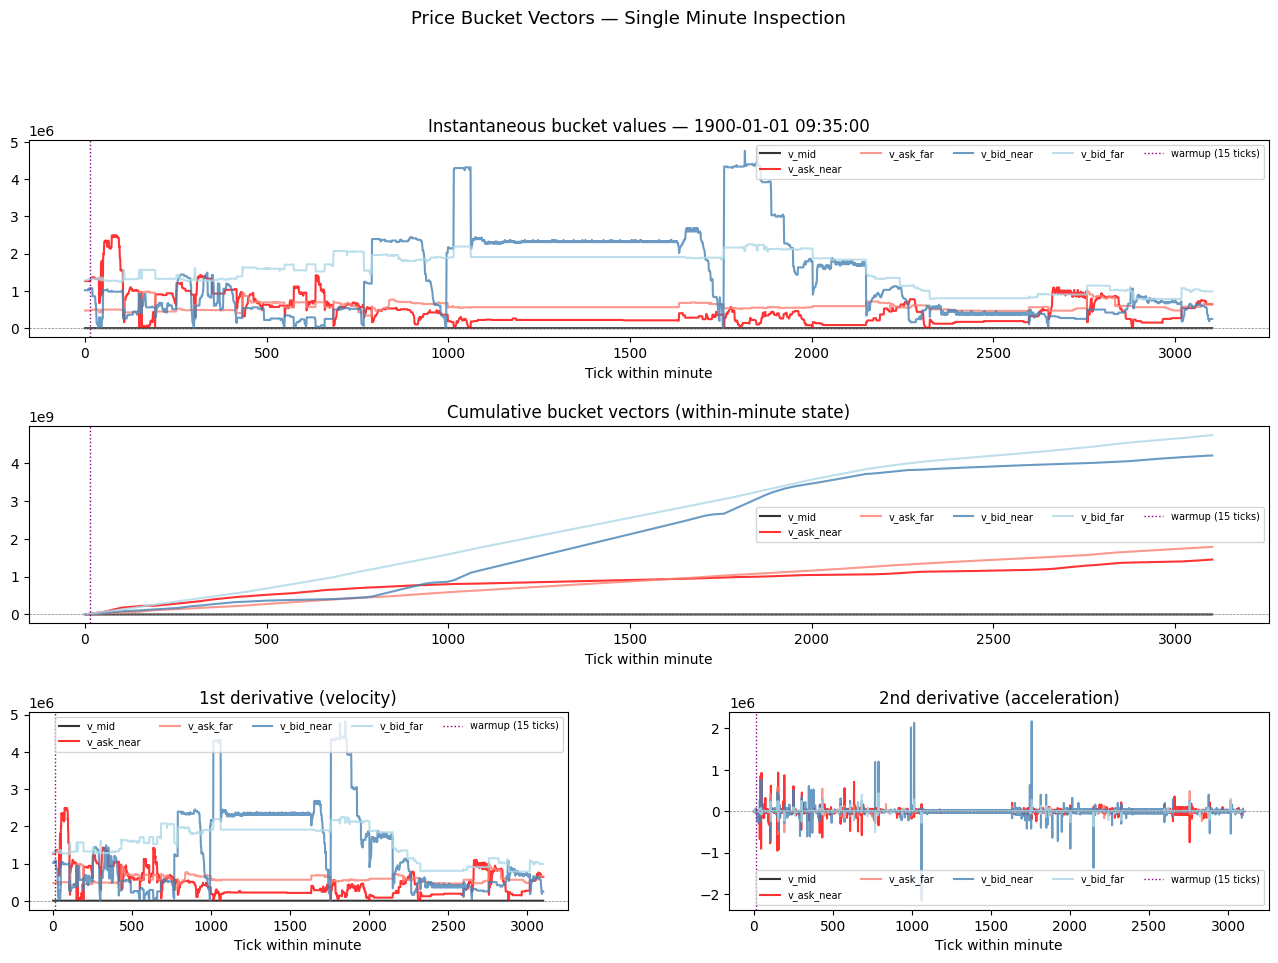

In [13]:
# ============================================================
# CELL 4: Visualise Bucket Vectors for a Sample Minute
# ============================================================
SAMPLE_MINUTE = train["Minute"].unique()[5]
sample = train[train["Minute"] == SAMPLE_MINUTE].reset_index(drop=True)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_raw = fig.add_subplot(gs[0, :])
ax_cum = fig.add_subplot(gs[1, :])
ax_d1  = fig.add_subplot(gs[2, 0])
ax_d2  = fig.add_subplot(gs[2, 1])

colors = ["black", "red", "salmon", "steelblue", "lightblue"]

for col, c in zip(BUCKET_COLS, colors):
    ax_raw.plot(sample[col].values, label=col, color=c, alpha=0.8)
    ax_cum.plot(sample[f"{col}_cum"].values, label=col, color=c, alpha=0.8)
    ax_d1.plot(sample[f"{col}_d1"].values, label=col, color=c, alpha=0.8)
    ax_d2.plot(sample[f"{col}_d2"].values, label=col, color=c, alpha=0.8)

for ax in [ax_raw, ax_cum, ax_d1, ax_d2]:
    ax.axvline(WARMUP_TICKS, color="purple", lw=1, ls=":", label=f"warmup ({WARMUP_TICKS} ticks)")
    ax.legend(fontsize=7, ncol=5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Tick within minute")

ax_raw.set_title(f"Instantaneous bucket values — {SAMPLE_MINUTE}")
ax_cum.set_title("Cumulative bucket vectors (within-minute state)")
ax_d1.set_title("1st derivative (velocity)")
ax_d2.set_title("2nd derivative (acceleration)")

plt.suptitle("Price Bucket Vectors — Single Minute Inspection", fontsize=13, y=1.01)
plt.show()

In [14]:
# ============================================================
# CELL 5: Signal Definition
# ============================================================
# BUY signal:
#   - tick_in_minute >= WARMUP_TICKS  → derivatives have enough history
#   - v_ask_near_d2 < 0               → near ask pressure decelerating (wall softening)
#   - v_mid_cum > 0                   → cumulative imbalance favours bid
#
# SELL signal: mirror logic.
# FALLBACK: fire at FALLBACK_SECONDS if no signal yet.

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"

def within_minute_seconds(row):
    return (row["Time_dt"] - row["Minute"]).total_seconds()


def buy_signal(row):
    if row["tick_in_minute"] < WARMUP_TICKS:
        return False
    elapsed = within_minute_seconds(row)
    if elapsed >= FALLBACK_SECONDS:
        return True
    if pd.isna(row["v_ask_near_d2"]) or pd.isna(row["v_mid_cum"]):
        return False
    return bool(row["v_ask_near_d2"] < 0 and row["v_mid_cum"] > 0)


def sell_signal(row):
    if row["tick_in_minute"] < WARMUP_TICKS:
        return False
    elapsed = within_minute_seconds(row)
    if elapsed >= FALLBACK_SECONDS:
        return True
    if pd.isna(row["v_bid_near_d2"]) or pd.isna(row["v_mid_cum"]):
        return False
    return bool(row["v_bid_near_d2"] < 0 and row["v_mid_cum"] < 0)


SIGNAL_FN = buy_signal if SIDE == "BUY" else sell_signal

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Fallback: {FALLBACK_SECONDS}s")

Side: BUY | Exec col: AskPrice_1
Warmup: 15 ticks | Fallback: 55s


In [15]:
# ============================================================
# CELL 6: Build Vectorised Signal + Simulate vs TWAP
# ============================================================
# Vectorised signal avoids slow row-apply for the full simulation.

train["warmup_ok"] = train["tick_in_minute"] >= WARMUP_TICKS

if SIDE == "BUY":
    train["signal"] = (
        train["warmup_ok"] &
        (train["v_ask_near_d2"] < 0) &
        (train["v_mid_cum"]     > 0)
    ).fillna(False) | (train["elapsed"] >= FALLBACK_SECONDS)
else:
    train["signal"] = (
        train["warmup_ok"] &
        (train["v_bid_near_d2"] < 0) &
        (train["v_mid_cum"]     < 0)
    ).fillna(False) | (train["elapsed"] >= FALLBACK_SECONDS)

print(f"Signal fires on {train['signal'].sum()} rows ({100*train['signal'].mean():.1f}% of ticks)")

twap_series = train.groupby("Minute")[EXEC_PRICE_COL].first().rename("twap_price")

first_idx = train[train["signal"]].groupby("Minute").apply(lambda g: g.index[0])
exec_rows = train.loc[first_idx, ["Minute", EXEC_PRICE_COL, "elapsed"]].copy()
exec_rows.columns = ["Minute", "pbv_price", "exec_second"]
exec_rows = exec_rows.set_index("Minute")

results_df = twap_series.to_frame().join(exec_rows)
results_df["fallback"]    = results_df["exec_second"] >= FALLBACK_SECONDS
results_df["improvement"] = (
    (results_df["twap_price"] - results_df["pbv_price"]) if SIDE == "BUY"
    else (results_df["pbv_price"] - results_df["twap_price"])
)

_nf = results_df[~results_df["fallback"]]
print("=" * 55)
print(f"  PBV v3 — {STOCK} — {SIDE}")
print("=" * 55)
print(f"  Total minutes     : {len(results_df)}")
print(f"  Fallback          : {results_df['fallback'].sum()} ({100*results_df['fallback'].mean():.1f}%)")
print(f"  Mean improvement  : ${results_df['improvement'].mean():.5f}")
print(f"  Median improv.    : ${results_df['improvement'].median():.5f}")
print(f"  % beating TWAP    : {100*(results_df['improvement'] > 0).mean():.1f}%")
print(f"  % non-fb beating  : {100*(_nf['improvement'] > 0).mean():.1f}%  (n={len(_nf)})")
print(f"  Mean exec second  : {results_df['exec_second'].mean():.1f}s")
print()
results_df.describe()

Signal fires on 101034 rows (23.5% of ticks)
  PBV v3 — INTC — BUY
  Total minutes     : 270
  Fallback          : 57 (21.1%)
  Mean improvement  : $0.00263
  Median improv.    : $0.00000
  % beating TWAP    : 18.5%
  % non-fb beating  : 6.1%  (n=213)
  Mean exec second  : 17.7s



,twap_price,pbv_price,exec_second,improvement
count,270.000000,270.000000,270.000000,270.000000
mean,27.160778,27.158148,17.726007,0.002630
std,0.200181,0.199722,21.890833,0.009173
min,26.800000,26.800000,0.011000,-0.020000
25%,26.952500,26.950000,1.612500,0.000000
50%,27.180000,27.180000,4.530000,0.000000
75%,27.340000,27.337500,32.047250,0.000000
max,27.580000,27.580000,56.371000,0.040000


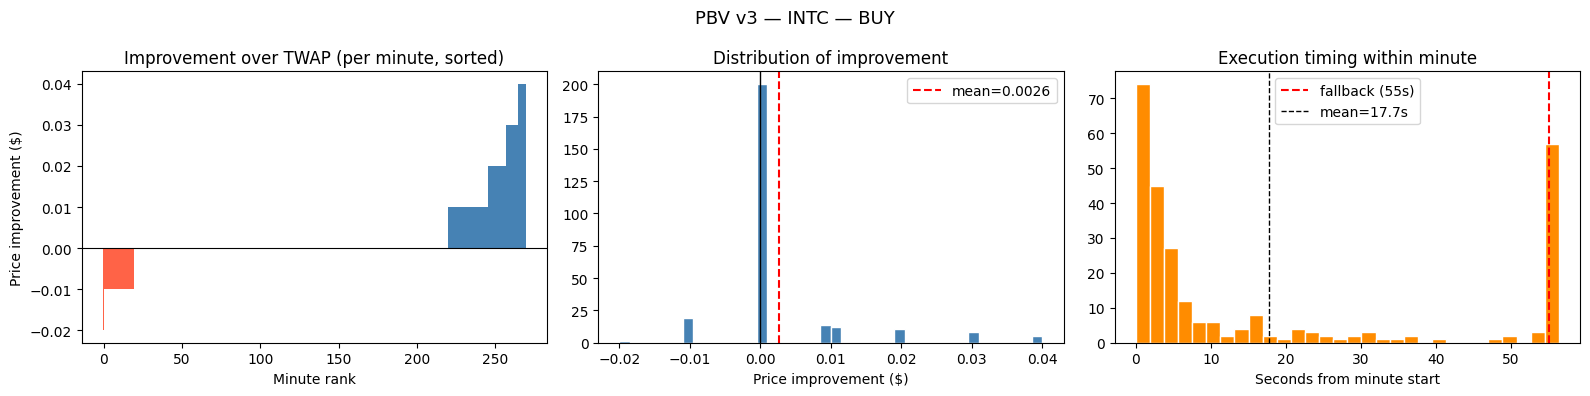

In [16]:
# ============================================================
# CELL 7: Results Visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(
    range(len(results_df)),
    results_df["improvement"].sort_values().values,
    color=["steelblue" if v >= 0 else "tomato"
           for v in results_df["improvement"].sort_values().values],
    width=1.0, edgecolor="none"
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Improvement over TWAP (per minute, sorted)")
axes[0].set_xlabel("Minute rank")
axes[0].set_ylabel("Price improvement ($)")

axes[1].hist(results_df["improvement"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(results_df["improvement"].mean(), color="red",
                linewidth=1.5, linestyle="--",
                label=f"mean={results_df['improvement'].mean():.4f}")
axes[1].set_title("Distribution of improvement")
axes[1].set_xlabel("Price improvement ($)")
axes[1].legend()

axes[2].hist(results_df["exec_second"], bins=30, color="darkorange", edgecolor="white")
axes[2].axvline(FALLBACK_SECONDS, color="red", linewidth=1.5,
                linestyle="--", label=f"fallback ({FALLBACK_SECONDS}s)")
axes[2].axvline(results_df["exec_second"].mean(), color="black",
                linewidth=1, linestyle="--",
                label=f"mean={results_df['exec_second'].mean():.1f}s")
axes[2].set_title("Execution timing within minute")
axes[2].set_xlabel("Seconds from minute start")
axes[2].legend()

plt.suptitle(f"PBV v3 — {STOCK} — {SIDE}", fontsize=13)
plt.tight_layout()
plt.show()

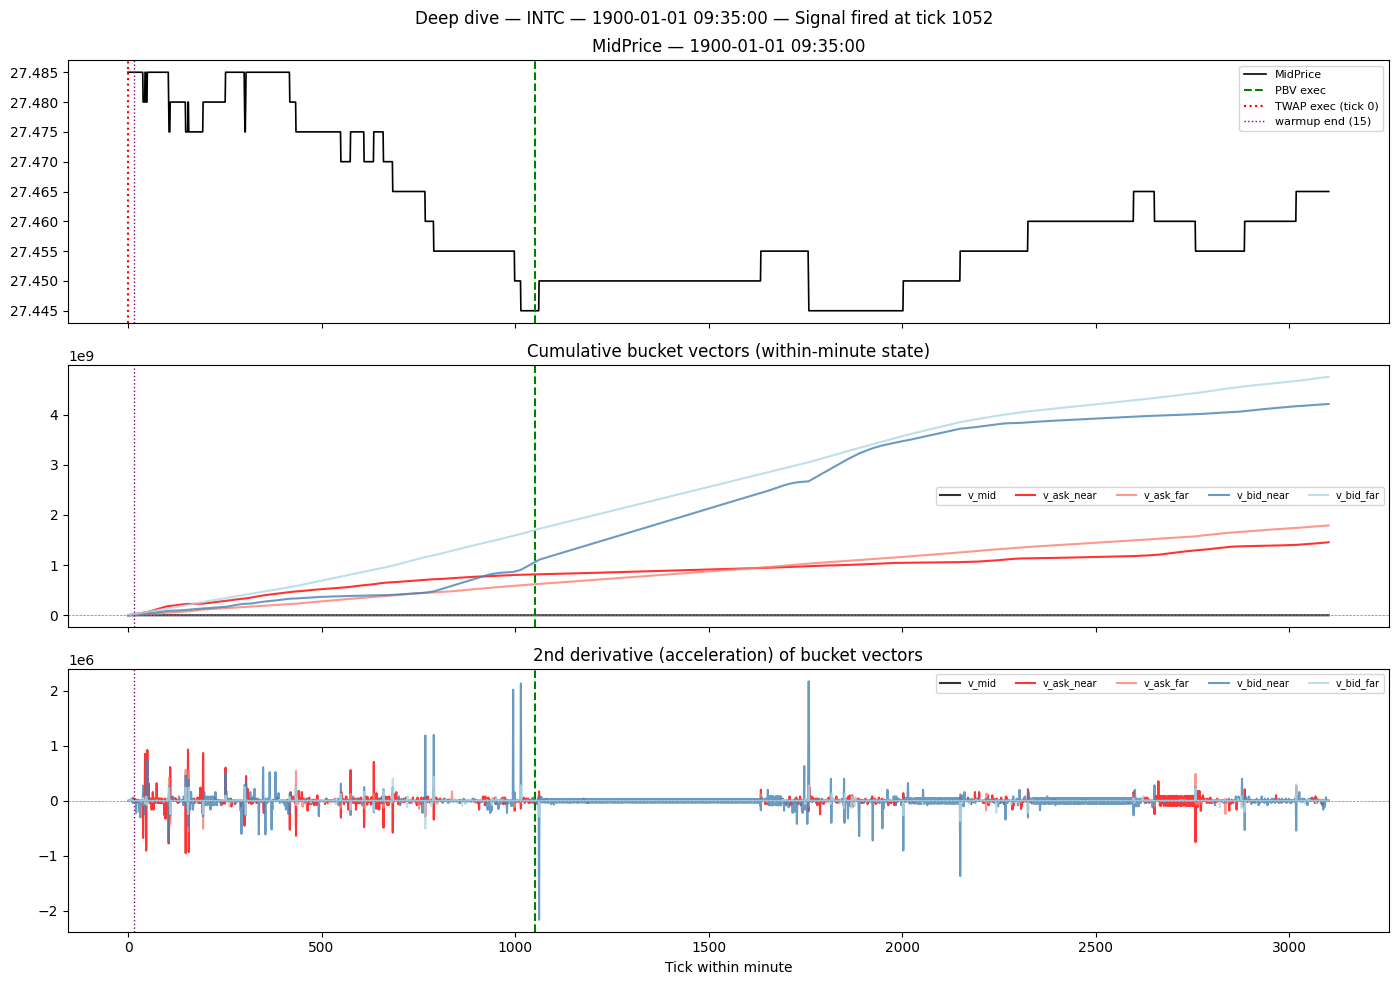

TWAP price : 27.4900
PBV price  : 27.4500
Improvement: 0.0400


In [17]:
# ============================================================
# CELL 8: Single-Minute Deep Dive — Signal Overlay
# ============================================================
INSPECT_MINUTE_IDX = 5
inspect_minute = train["Minute"].unique()[INSPECT_MINUTE_IDX]
sample = train[train["Minute"] == inspect_minute].reset_index(drop=True)
sample["signal"] = sample.apply(SIGNAL_FN, axis=1)

fired_idx = sample[sample["signal"]].index[0] if sample["signal"].any() else len(sample) - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample["MidPrice"].values, color="black", linewidth=1.2, label="MidPrice")
axes[0].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5, label="PBV exec")
axes[0].axvline(0, color="red", linestyle=":", linewidth=1.5, label="TWAP exec (tick 0)")
axes[0].axvline(WARMUP_TICKS, color="purple", linestyle=":", linewidth=1, label=f"warmup end ({WARMUP_TICKS})")
axes[0].set_title(f"MidPrice — {inspect_minute}")
axes[0].legend(fontsize=8)

colors = ["black", "red", "salmon", "steelblue", "lightblue"]
for col, c in zip(BUCKET_COLS, colors):
    axes[1].plot(sample[f"{col}_cum"].values, label=col, color=c, alpha=0.8)
axes[1].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5)
axes[1].axvline(WARMUP_TICKS, color="purple", linestyle=":", linewidth=1)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_title("Cumulative bucket vectors (within-minute state)")
axes[1].legend(fontsize=7, ncol=5)

for col, c in zip(BUCKET_COLS, colors):
    axes[2].plot(sample[f"{col}_d2"].values, label=col, color=c, alpha=0.8)
axes[2].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5)
axes[2].axvline(WARMUP_TICKS, color="purple", linestyle=":", linewidth=1)
axes[2].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[2].set_title("2nd derivative (acceleration) of bucket vectors")
axes[2].set_xlabel("Tick within minute")
axes[2].legend(fontsize=7, ncol=5)

plt.suptitle(f"Deep dive — {STOCK} — {inspect_minute} — Signal fired at tick {fired_idx}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"TWAP price : {sample.iloc[0][EXEC_PRICE_COL]:.4f}")
print(f"PBV price  : {sample.iloc[fired_idx][EXEC_PRICE_COL]:.4f}")
print(f"Improvement: {(sample.iloc[0][EXEC_PRICE_COL] - sample.iloc[fired_idx][EXEC_PRICE_COL]):.4f}")

Running cross-stock pipeline...
Done.

  Cross-stock summary — BUY side — PBV v3 (warmup=15 ticks)
       Minutes   Mean $ Beat TWAP % Fallback % Mean exec s Non-fb beat %  Non-fb n
Stock                                                                             
AMZN       270  0.00841        37.0       10.0        12.7          36.2       243
GOOG       270  0.00089        45.6       24.8        20.1          42.4       203
INTC       270  0.00263        18.5       21.1        17.7           6.1       213
MSFT       270  0.00285        20.7       24.8        20.2           7.4       203


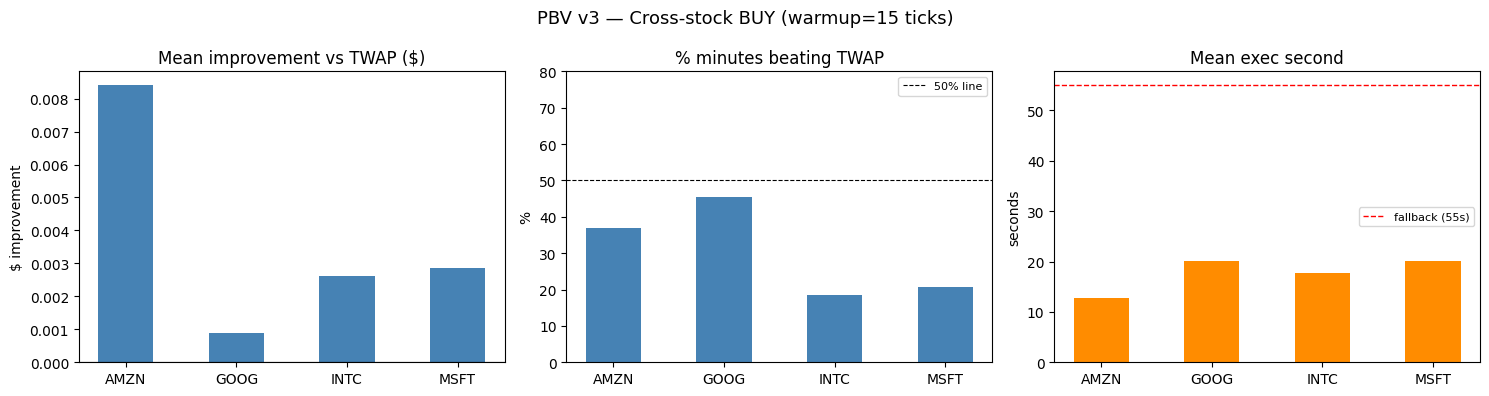

In [18]:
# ============================================================
# CELL 9: Cross-Stock Evaluation
# ============================================================
STOCKS_ALL = ["AMZN", "GOOG", "INTC", "MSFT"]

def run_stock(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    _BCOLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far"]
    grp = d.groupby("Minute")
    for col in _BCOLS:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    warmup_ok = d["tick_in_minute"] >= WARMUP_TICKS
    d["signal"] = (
        warmup_ok &
        (d["v_ask_near_d2"] < 0) &
        (d["v_mid_cum"]     > 0)
    ).fillna(False) | (d["elapsed"] >= FALLBACK_SECONDS)

    twap_s    = d.groupby("Minute")["AskPrice_1"].first().rename("twap_price")
    first_idx = d[d["signal"]].groupby("Minute").apply(lambda g: g.index[0])
    er        = d.loc[first_idx, ["Minute", "AskPrice_1", "elapsed"]].copy()
    er.columns = ["Minute", "pbv_price", "exec_second"]
    er        = er.set_index("Minute")
    res       = twap_s.to_frame().join(er)
    res["fallback"]    = res["exec_second"] >= FALLBACK_SECONDS
    res["improvement"] = res["twap_price"] - res["pbv_price"]

    _nf = res[~res["fallback"]]
    return {
        "stock":    stock,
        "minutes":  len(res),
        "mean_imp": res["improvement"].mean(),
        "beat_pct": (res["improvement"] > 0).mean() * 100,
        "fb_pct":   res["fallback"].mean() * 100,
        "exec_s":   res["exec_second"].mean(),
        "nfb_beat": (_nf["improvement"] > 0).mean() * 100,
        "nfb_n":    len(_nf),
    }

print("Running cross-stock pipeline...")
stock_res = {s: run_stock(s) for s in STOCKS_ALL}
print("Done.")

rows = []
for s, r in stock_res.items():
    rows.append({
        "Stock":       s,
        "Minutes":     r["minutes"],
        "Mean $":      f"{r['mean_imp']:.5f}",
        "Beat TWAP %": f"{r['beat_pct']:.1f}",
        "Fallback %":  f"{r['fb_pct']:.1f}",
        "Mean exec s": f"{r['exec_s']:.1f}",
        "Non-fb beat %": f"{r['nfb_beat']:.1f}",
        "Non-fb n":    r["nfb_n"],
    })

summary = pd.DataFrame(rows).set_index("Stock")
print("\n" + "="*70 + "\n  Cross-stock summary — BUY side — PBV v3 (warmup=" + str(WARMUP_TICKS) + " ticks)\n" + "="*70)
print(summary.to_string())

x, width = np.arange(len(STOCKS_ALL)), 0.5
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(x, [stock_res[s]["mean_imp"] for s in STOCKS_ALL], width, color="steelblue")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(STOCKS_ALL)
axes[0].set(title="Mean improvement vs TWAP ($)", ylabel="$ improvement")

axes[1].bar(x, [stock_res[s]["beat_pct"] for s in STOCKS_ALL], width, color="steelblue")
axes[1].axhline(50, color="black", lw=0.8, ls="--", label="50% line")
axes[1].set_xticks(x); axes[1].set_xticklabels(STOCKS_ALL)
axes[1].set(title="% minutes beating TWAP", ylabel="%", ylim=(0, 80))
axes[1].legend(fontsize=8)

axes[2].bar(x, [stock_res[s]["exec_s"] for s in STOCKS_ALL], width, color="darkorange")
axes[2].axhline(FALLBACK_SECONDS, color="red", lw=1, ls="--", label=f"fallback ({FALLBACK_SECONDS}s)")
axes[2].set_xticks(x); axes[2].set_xticklabels(STOCKS_ALL)
axes[2].set(title="Mean exec second", ylabel="seconds")
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v3 — Cross-stock BUY (warmup={WARMUP_TICKS} ticks)", fontsize=13)
plt.tight_layout()
plt.show()